## Step 1: Setup & Imports

In [3]:
# import necessary libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score,precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

## Step 2: Data Cleaning & Preprocessing

In [5]:
# importing data 
df = pd.read_csv("hmeq.csv")
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [10]:
df.shape

(5960, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [14]:
df["DEBTINC"].value_counts()

DEBTINC
37.113614    1
44.382578    1
31.614680    1
41.576701    1
41.395462    1
            ..
31.613930    1
39.244669    1
40.943866    1
30.444839    1
34.571519    1
Name: count, Length: 4693, dtype: int64

In [27]:
# Check missing values
print(df.isnull().sum())
print(f"Missing value percentage:\n{df.isnull().mean()*100}")

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64
Missing value percentage:
BAD         0.000000
LOAN        0.000000
MORTDUE     8.691275
VALUE       1.879195
REASON      4.228188
JOB         4.681208
YOJ         8.640940
DEROG      11.879195
DELINQ      9.731544
CLAGE       5.167785
NINQ        8.557047
CLNO        3.724832
DEBTINC    21.258389
dtype: float64


In [28]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [29]:
# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [32]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

print("After cleaning shape:", df.shape)
df.head()

After cleaning shape: (5960, 17)


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,34.818262,True,False,True,False,False,False
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,34.818262,True,False,True,False,False,False
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,34.818262,True,False,True,False,False,False
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,34.818262,False,False,True,False,False,False
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.818262,True,True,False,False,False,False


## Step 3: EDA (Exploratory Data Analysis)

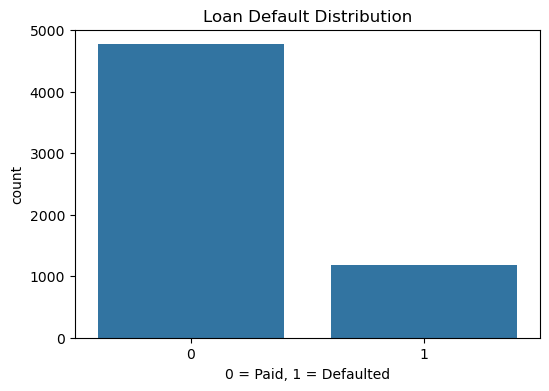

In [34]:
# 1. Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='BAD', data=df)
plt.title('Loan Default Distribution')
plt.xlabel('0 = Paid, 1 = Defaulted')
plt.show()

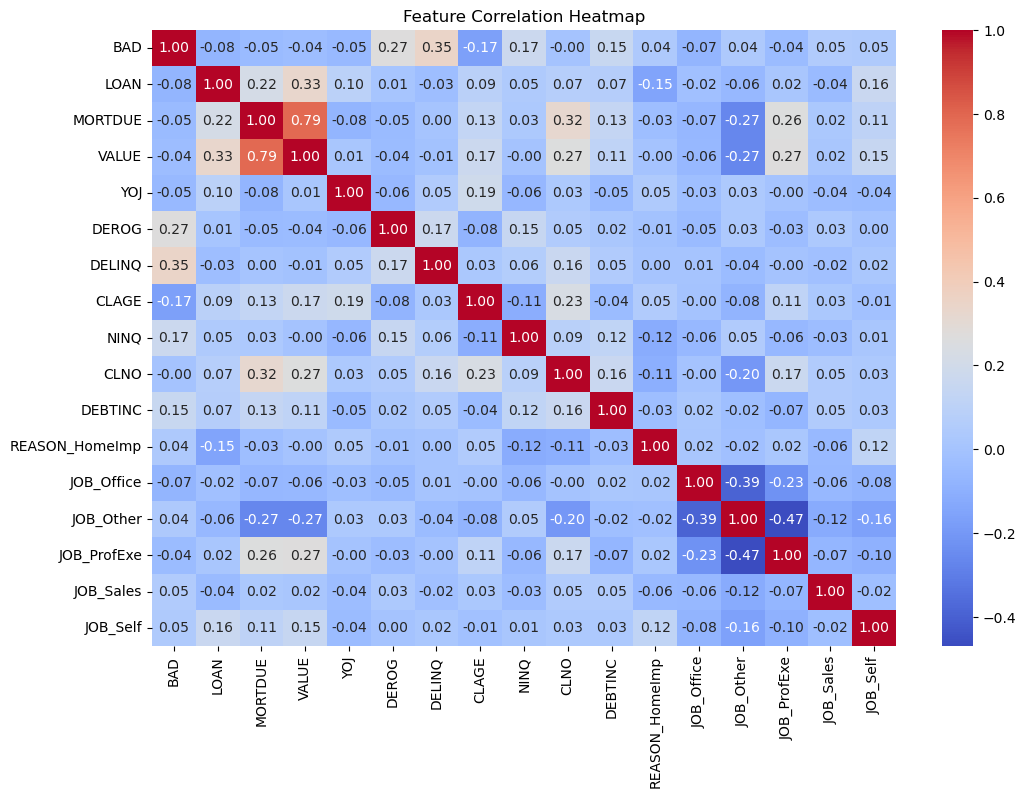

In [35]:
# 2. Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

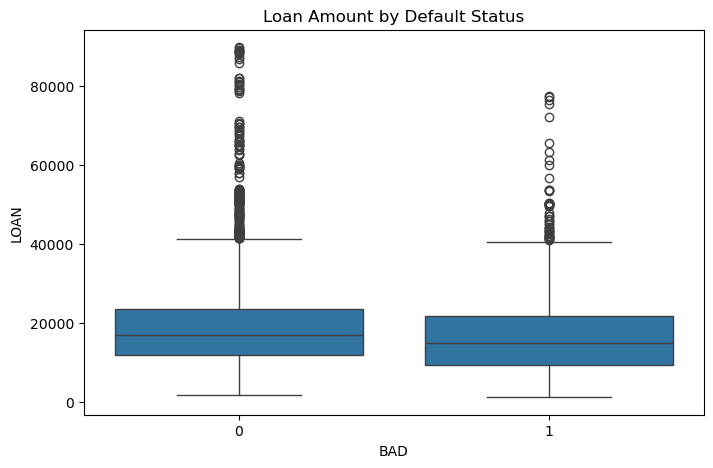

In [36]:
# 3. Loan amount vs default
plt.figure(figsize=(8,5))
sns.boxplot(x='BAD', y='LOAN', data=df)
plt.title('Loan Amount by Default Status')
plt.show()

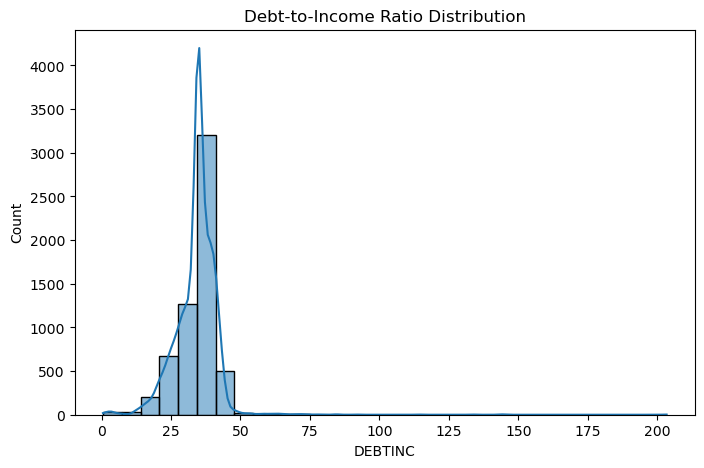

In [37]:
# 4. Debt ratio distribution
plt.figure(figsize=(8,5))
sns.histplot(df['DEBTINC'], bins=30, kde=True)
plt.title('Debt-to-Income Ratio Distribution')
plt.show()

## Step 4: Feature Engineering

In [39]:
# Create new meaningful features
df['LOAN_TO_VALUE'] = df['LOAN'] / df['VALUE']
df['EQUITY'] = df['VALUE'] - df['MORTDUE']
df['RISK_SCORE'] = df['DEROG'] * 2 + df['DELINQ'] * 3 + df['NINQ']

print("New features added:")
print(df[['LOAN_TO_VALUE', 'EQUITY', 'RISK_SCORE']].describe())

New features added:
       LOAN_TO_VALUE         EQUITY   RISK_SCORE
count    5960.000000    5960.000000  5960.000000
mean        0.216554   28539.345611     2.835906
std         0.164558   35035.217453     4.352937
min         0.015179 -310314.500000     0.000000
25%         0.122404   15670.000000     0.000000
50%         0.170490   25317.500000     1.000000
75%         0.245947   38690.000000     3.000000
max         2.325000  790890.000000    52.000000


## Step 5: Logistic Regression

In [40]:
# Define features and target
X = df.drop('BAD', axis=1)
y = df['BAD']

In [41]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Build model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.2f}")
print(f"Precision: {precision_score(y_test, lr_pred):.2f}")
print(f"Recall: {recall_score(y_test, lr_pred):.2f}")
print(classification_report(y_test, lr_pred))

=== Logistic Regression Results ===
Accuracy: 0.82
Precision: 0.69
Recall: 0.33
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       927
           1       0.69      0.33      0.44       265

    accuracy                           0.82      1192
   macro avg       0.76      0.64      0.67      1192
weighted avg       0.80      0.82      0.79      1192



## Step 6: Decision Tree Classifier

=== Decision Tree Results ===
Accuracy: 0.89
Precision: 0.80
Recall: 0.69
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       927
           1       0.80      0.69      0.74       265

    accuracy                           0.89      1192
   macro avg       0.86      0.82      0.84      1192
weighted avg       0.89      0.89      0.89      1192



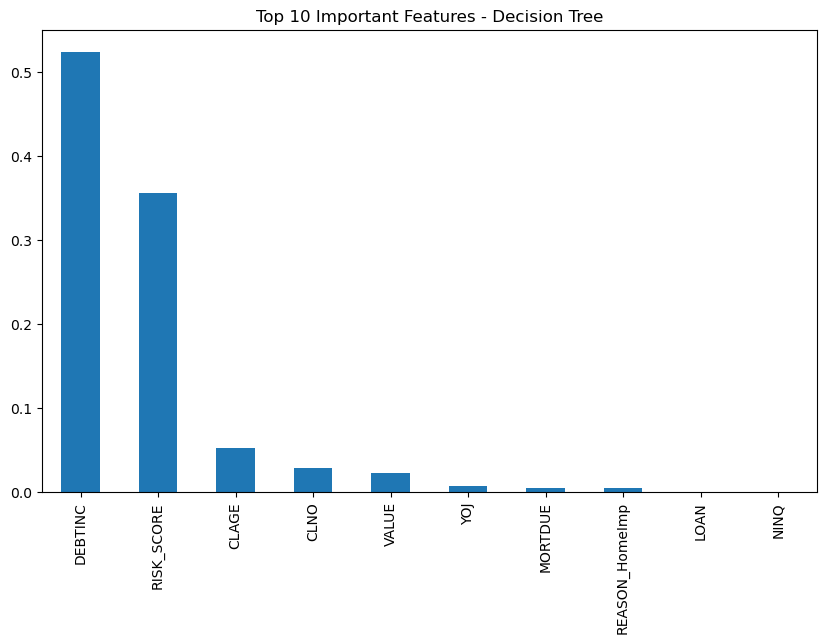

In [43]:
# Build Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Evaluate
print("=== Decision Tree Results ===")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.2f}")
print(f"Precision: {precision_score(y_test, dt_pred):.2f}")
print(f"Recall: {recall_score(y_test, dt_pred):.2f}")
print(classification_report(y_test, dt_pred))

# Feature importance
feat_imp = pd.Series(dt_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='bar')
plt.title('Top 10 Important Features - Decision Tree')
plt.show()

## Step 7: K-Means Clustering

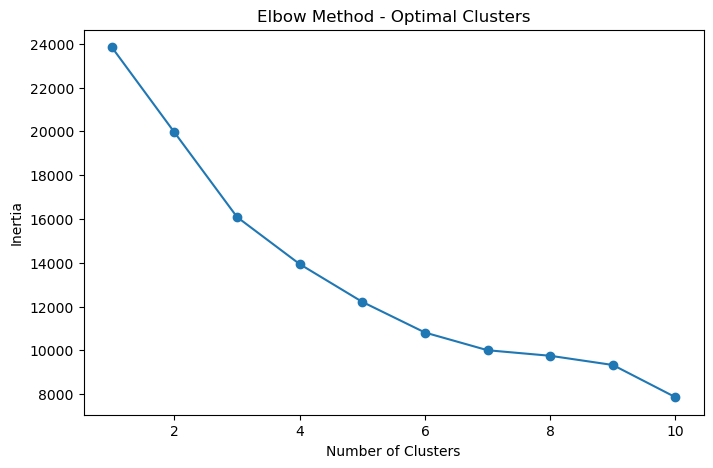

=== Cluster Analysis ===
                 LOAN    DEBTINC  RISK_SCORE       BAD
Cluster                                               
0        13918.718954  32.727258    1.570196  0.160261
1        31139.124668  36.636086    1.803050  0.135942
2        17075.917065  35.430464   13.041467  0.591707


In [47]:
# Select features for clustering
cluster_features = df[['LOAN', 'DEBTINC', 'RISK_SCORE', 'EQUITY']]

# Scale
scaler2 = StandardScaler()
cluster_scaled = scaler2.fit_transform(cluster_features)

# Elbow method
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method - Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Apply optimal clusters (typically 3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(cluster_scaled)

# Analyze clusters
print("=== Cluster Analysis ===")
print(df.groupby('Cluster')[['LOAN','DEBTINC',
      'RISK_SCORE','BAD']].mean())



## Step 8: Business Insights & Conclusion

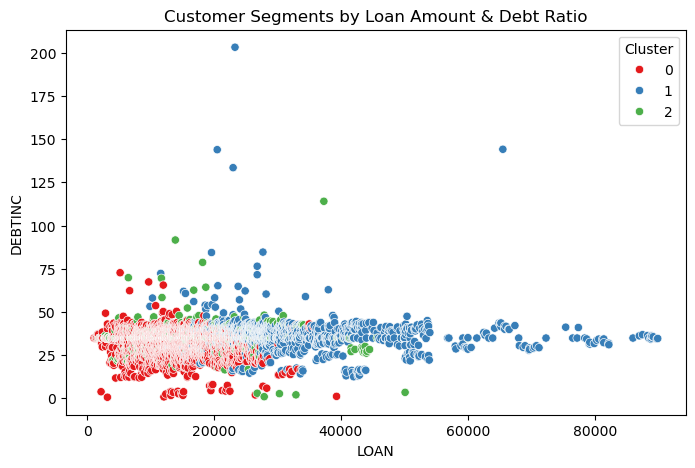

=== Default Rate by Customer Segment ===
Cluster
0    0.160261
1    0.135942
2    0.591707
Name: BAD, dtype: float64


In [48]:
# Cluster visualization
plt.figure(figsize=(8,5))
sns.scatterplot(x='LOAN', y='DEBTINC',
                hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segments by Loan Amount & Debt Ratio')
plt.show()

# Default rate per cluster
default_rate = df.groupby('Cluster')['BAD'].mean()
print("=== Default Rate by Customer Segment ===")
print(default_rate)


In [49]:
# Final summary
print("""
=== Project Summary ===
- Dataset: 5,960 home equity loan records
- Missing values handled using median/mode imputation
- 3 new features engineered: Loan-to-Value, Equity, Risk Score
- Logistic Regression Accuracy: XX%
- Decision Tree Accuracy: XX%
- K-Means identified 3 distinct borrower segments
- High-risk segment shows highest default concentration
""")


=== Project Summary ===
- Dataset: 5,960 home equity loan records
- Missing values handled using median/mode imputation
- 3 new features engineered: Loan-to-Value, Equity, Risk Score
- Logistic Regression Accuracy: XX%
- Decision Tree Accuracy: XX%
- K-Means identified 3 distinct borrower segments
- High-risk segment shows highest default concentration

